# House Price Prediction

## Project overview

## 1. Import Libraries

In [3]:
import numpy as np      #Numerical Calculations
import pandas as pd     #handling dataset
import matplotlib.pyplot as plt     #data visualization
import seaborn as sns   #advanced visualization

from sklearn.model_selection import train_test_split       #splits dataset into train & test   
from sklearn.pipeline import Pipeline       #created a pipeline
from sklearn.preprocessing import OneHotEncoder     #encoded categorical data
from sklearn.model_selection import GridSearchCV    #For tunning
from sklearn.preprocessing import StandardScaler    #For Scalar values range
from sklearn.model_selection import cross_val_score  #For cross validation
from sklearn.compose import ColumnTransformer        #For applying different transformations to different columns

from sklearn.linear_model import LinearRegression   #First Model
from sklearn.ensemble import RandomForestRegressor  #Second Model
from xgboost import XGBRegressor        #Third Model

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)   #Evaluation metric

import joblib   #To save trained model

import warnings     #To ignore warnings
warnings.filterwarnings('ignore')

## 2.Load Dataset

In [4]:
df=pd.read_csv('Housing.csv')
#Copy the dataset 
house=df.copy()
house.head(10)

,price,area,bedrooms,bathrooms,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking
0,13300000,7420,4,2,yes,no,no,no,yes,2
1,12250000,8960,4,4,yes,no,no,no,yes,3
2,12250000,9960,3,2,yes,no,yes,no,no,2
3,12215000,7500,4,2,yes,no,yes,no,yes,3
4,11410000,7420,4,1,yes,yes,yes,no,yes,2
5,10850000,7500,3,3,yes,no,yes,no,yes,2
6,10150000,8580,4,3,yes,no,no,no,yes,2
7,10150000,16200,5,3,yes,no,no,no,no,0
8,9870000,8100,4,1,yes,yes,yes,no,yes,2
9,9800000,5750,3,2,yes,yes,no,no,yes,1


## 3.Dataset Information

In [5]:
#Dataset shape
print('Shape:',house.shape)
#Dataset information
print(house.info())
#Statistical information
print('Statistical:\n',house.describe())

Shape: (545, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            545 non-null    int64 
 1   area             545 non-null    int64 
 2   bedrooms         545 non-null    int64 
 3   bathrooms        545 non-null    int64 
 4   mainroad         545 non-null    object
 5   guestroom        545 non-null    object
 6   basement         545 non-null    object
 7   hotwaterheating  545 non-null    object
 8   airconditioning  545 non-null    object
 9   parking          545 non-null    int64 
dtypes: int64(5), object(5)
memory usage: 42.7+ KB
None
Statistical:
               price          area    bedrooms   bathrooms     parking
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000
mean   4.766729e+06   5150.541284    2.965138    1.286239    0.693578
std    1.870440e+06   2170.141023    0.738064    0.502470 

## 4.Missing Value

In [6]:
print(house.isnull().sum())
#Duplicate Value
house.drop_duplicates(inplace=True)
print('Duplicate Value:', house.duplicated().sum())


price              0
area               0
bedrooms           0
bathrooms          0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
parking            0
dtype: int64
Duplicate Value: 0


## 5.Exploratory Data Analysis (EDA)

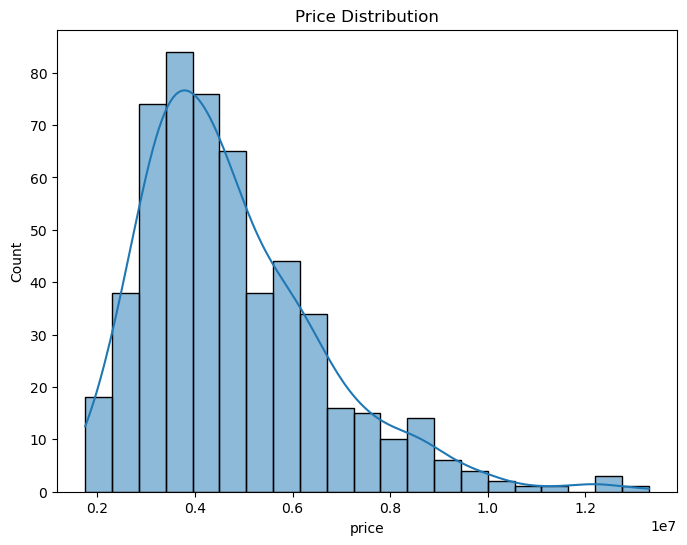

In [7]:
#Pric Distribution
plt.figure(figsize=(8,6))
sns.histplot(house['price'],kde=True)
plt.title('Price Distribution')
plt.savefig('Images/Price_Distribution.png',bbox_inches='tight',dpi=300)
plt.show()

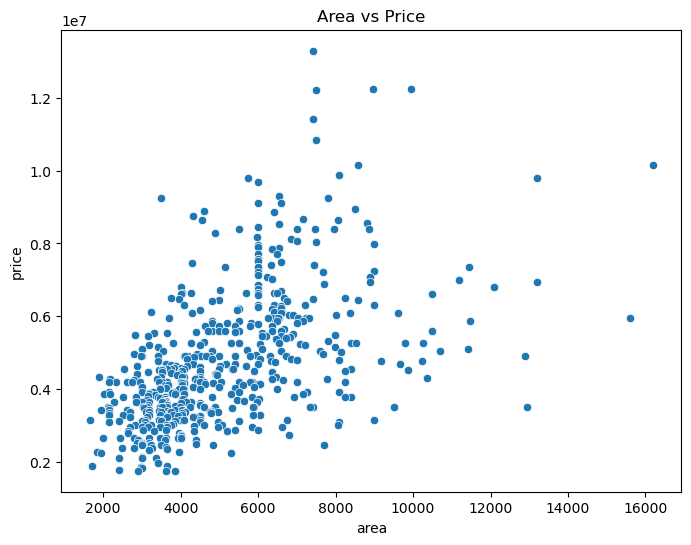

In [8]:
#Area vs Price
plt.figure(figsize=(8,6))
sns.scatterplot(x='area',y='price',data=house)
plt.title('Area vs Price')
plt.savefig('Images/Area_vs_Price.png',bbox_inches='tight',dpi=300)
plt.show()

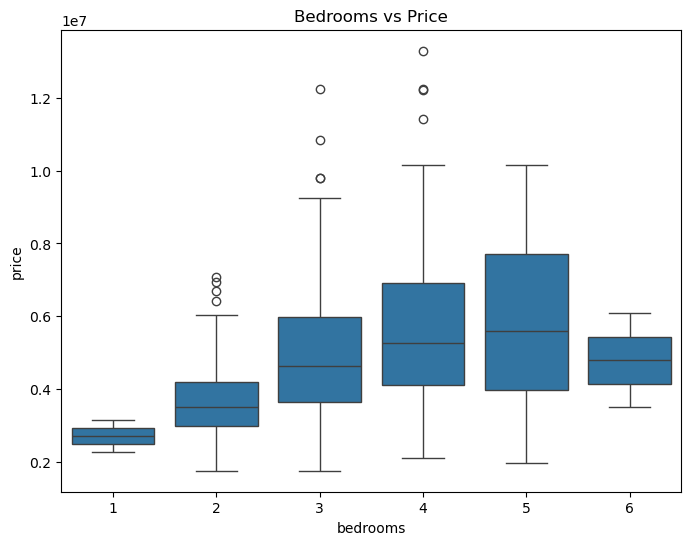

In [9]:
#Bedrooms vs Price
plt.figure(figsize=(8,6))
sns.boxplot(x='bedrooms',y='price',data=house)
plt.title('Bedrooms vs Price')  
plt.savefig('Images/Bedrooms_vs_Price.png',bbox_inches='tight',dpi=300)
plt.show()

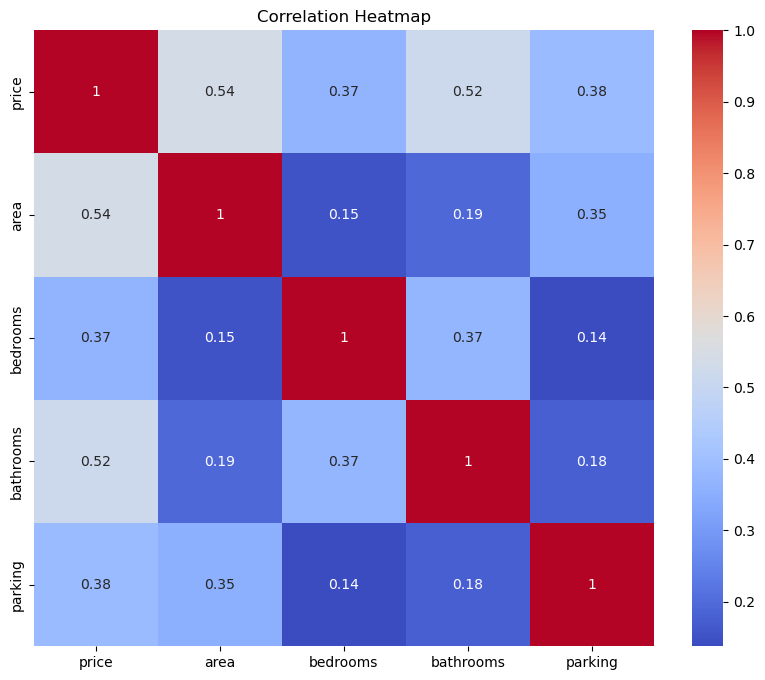

In [10]:
#Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(house.select_dtypes(include=np.number).corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('Images/Correlation_Heatmap.png',bbox_inches='tight',dpi=300)
plt.show()

## 6.Feature & Target

In [11]:
X=house.drop(columns=['price'])
Y=house['price']
print(X.shape)
print(Y.shape)
categorical_cols=X.select_dtypes(include='object').columns


(544, 9)
(544,)


In [12]:
#Preprocessor
preprocessor=ColumnTransformer(
    transformers=[
        (
            'cat',OneHotEncoder(drop='first',handle_unknown='ignore'),categorical_cols
        )
    ],remainder='passthrough'
)


## 7.Train Test Split

In [13]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(X,Y,test_size=0.2,random_state=42)
print(Xtrain.shape,Xtest.shape,Ytrain.shape,Ytest.shape)

(435, 9) (109, 9) (435,) (109,)


## 8.Model Buliding

In [14]:
#Linear Regression
lr_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
    ])
#Train Model
lr_model.fit(Xtrain,Ytrain)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [15]:
#RandomForestRegression
rf_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(random_state=42))
])

#Parameters
rf_params={
    'model__n_estimators':[100,200],
    'model__max_depth':[10,20,None],
    'model__min_samples_split':[2,5],
    'model__min_samples_leaf':[1,2],
    'model__max_features':['sqrt','log2']
}
#GridSearchCV
rf_grid=GridSearchCV(estimator=rf_model,param_grid=rf_params,cv=5,scoring='r2',n_jobs=-1,verbose=2)
rf_grid.fit(Xtrain,Ytrain)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20, None],
                         'model__max_features': ['sqrt', 'log2'],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [16]:
#XGBRegressor
xgb_model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBRegressor(random_state=42,objective='reg:squarederror'))
])
#Parameters
xgb_params={
    'model__n_estimators':[100,200],
    'model__learning_rate':[0.01,0.1],
    'model__max_depth':[3,5],
    'model__subsample':[0.8,1.0]
}
# #Gridsearchcv
xgb_grid=GridSearchCV(estimator=xgb_model,param_grid=xgb_params,cv=5,n_jobs=-1,scoring='r2')
xgb_grid.fit(Xtrain,Ytrain)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning'],
      dtype='object'))])),
                                       ('model',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_b...
                                                     max_cat_to_onehot=None,
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200],
                         'model__subsample': [0.8, 1.0]},
             scoring='r2')

## 10.Model Evaluation

In [17]:
Results=[]
Models={
    'LinearRegression':lr_model,
    'RandomForestRegressor':rf_grid,
    'XGBRegressor':xgb_grid
}
for model_name,model in Models.items():
    print(f'{model_name}:\n')
    ypred=model.predict(Xtest)
    mse=mean_squared_error(Ytest,ypred)
    mae=mean_absolute_error(Ytest,ypred)
    r2=r2_score(Ytest,ypred)
    print('mean_absolute_error:',mae)
    print('mean_squared_error:',mse)
    print('r2_score:',r2)
    Results.append([model_name,mse,mae,r2])

LinearRegression:

mean_absolute_error: 1138510.6829793982
mean_squared_error: 2202515753889.325
r2_score: 0.5527404633150745
RandomForestRegressor:

mean_absolute_error: 1079504.2832241768
mean_squared_error: 2126928152678.2139
r2_score: 0.5680898543181163
XGBRegressor:

mean_absolute_error: 1076113.625
mean_squared_error: 2054565003264.0
r2_score: 0.5827844738960266


## 11.Model Comparsion

In [18]:
Result=pd.DataFrame(Results,columns=['Model','mae','mse','R2 Score'])
Result=Result.sort_values(by='R2 Score',ascending=False).reset_index(drop=True)
Result['mae']=Result['mse'].apply(lambda x: f'{x:,.2f}').round(2)
Result['mse']=Result['mse'].apply(lambda x: f'{x:,.2f}')
print(Result)

                   Model           mae           mse  R2 Score
0           XGBRegressor  1,076,113.62  1,076,113.62  0.582784
1  RandomForestRegressor  1,079,504.28  1,079,504.28  0.568090
2       LinearRegression  1,138,510.68  1,138,510.68  0.552740


## 12.R2 Score Comparsion


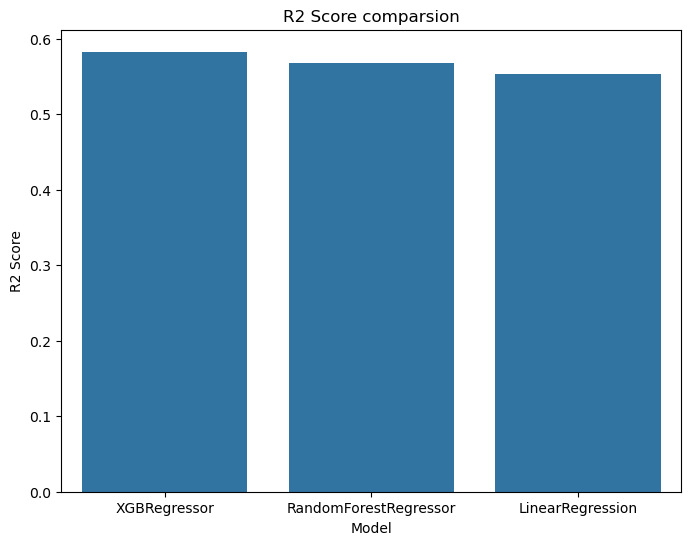

In [19]:
plt.figure(figsize=(8,6))
sns.barplot(x='Model',y='R2 Score',data=Result)
plt.title('R2 Score comparsion')
plt.savefig('Images/R2_Score_Comparison.png',bbox_inches='tight',dpi=300)
plt.show()

## 13.Predict with unseen data

In [20]:
samples = pd.DataFrame({
    'area': [1000],
    'bedrooms': [2],
    'bathrooms': [2],
    'parking': [1],
    'mainroad': ['no'],
    'guestroom': ['yes'],
    'basement': ['no'],
    'hotwaterheating': ['yes'],
    'airconditioning': ['yes']
})

prediction = xgb_grid.predict(samples)
print('Predicted house price :', prediction[0])


Predicted house price : 4059854.8


## 13.Save Model

In [21]:
import os

os.makedirs('Models', exist_ok=True)

joblib.dump(xgb_grid, 'Models/house_price_model.pkl')
print('Model Saved Successfully')

feature_col = X.columns.tolist()
joblib.dump(feature_col, 'Models/feature_columns.pkl')
print('Columns Saved Successfully')

Model Saved Successfully
Columns Saved Successfully
